<a href="https://colab.research.google.com/github/reneeka-sharma/NeoSOFT_reeneka/blob/main/ml%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ppm_dummy_data.csv to ppm_dummy_data.csv


In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [4]:
df = pd.read_csv("ppm_dummy_data.csv")

In [5]:
print("First 5 Rows:")
display(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Info:")
df.info()


First 5 Rows:


,Account_Key,Billing_Num,Book_key,Book_Cycle,Billing_Cycle,Balance,BAR,Total_Due,TDtoBRatio,Instalment,...,HomeNumber3_TelType,HomeNumber3_LatestDate,Employer1_OriginalEmployerName,Employer1_Occupation,Employer1_LatestDate,Employer1_EmployerTelephone,Employer2_OriginalEmployerName,Employer2_Occupation,Employer2_LatestDate,Employer2_EmployerTelephone
0,1104955506,2,664,Nov 2025,1,54297.61,0.9245,50199.54,0.9245,1274.78,...,Cell,2020-09-06,NaN,Consultant,2024-07-24,719015621.0,Shoprite,Manager,2019-09-14,NaN
1,1104951152,4,6634,Oct 2025,2,40717.83,0.3927,15990.69,0.3927,1382.79,...,Cell,2024-05-14,Eskom,Manager,2023-08-02,810378947.0,Eskom,NaN,2019-11-21,NaN
2,1106011444,1,6637,Nov 2025,4,14947.46,0.4821,7206.31,0.4821,494.67,...,Home,2021-12-18,Self Employed,NaN,2021-07-25,NaN,Self Employed,NaN,NaN,NaN
3,1106019167,4,6647,Nov 2025,3,44162.96,0.9494,41927.03,0.9494,1657.20,...,NaN,NaN,Sasol,Driver,NaN,NaN,Self Employed,Director,NaN,NaN
4,1106014362,1,664,Nov 2025,2,26620.48,0.4033,10735.72,0.4033,1491.31,...,Work,2023-08-16,NaN,NaN,2019-12-17,765304032.0,XYZ Ltd,Technician,2021-07-05,NaN



Shape:
(1000, 146)

Columns:
['Account_Key', 'Billing_Num', 'Book_key', 'Book_Cycle', 'Billing_Cycle', 'Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 'Instalment', 'Opening_Balance', 'Opening_Arrears', 'Opening_Total_Due', 'Opening_acc_status', 'Opening_acc_age', 'Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days', 'Due_90days', 'Due_120days', 'Due_150days', 'Due_180days', 'Due_210days', 'Current_per', 'Xdays_per', '30days_per', '60days_per', '90days_per', '120days_per', '150days_per', '180days_per', '210days_per', 'Deliquency', 'DC', 'TDtoBal', 'ARtoBal', 'Recency', 'Account_Age', 'Case_Age', 'Original_Band', 'Current_Band', 'Existing_Account', 'PropensistyToRol', 'BehaviourRiskScore', 'PaymentProjectionScore', 'Digigroup', 'Contact_Score', 'Credit_Risk', 'Missing', 'PContacts', 'PRPCs', 'PSMSs', 'PEmails', 'PLetters', 'PDOs', 'PPTPs', 'PAttempts', 'Previous_Account', 'Previous_Total_Due', 'Previous_Payment', 'Previous_Payment_Amount', 'Previous_Payment_Perc', 'Previous_Cure', 'Curr


Current Payment Value Counts:
Current_Payment
0    741
1    259
Name: count, dtype: int64


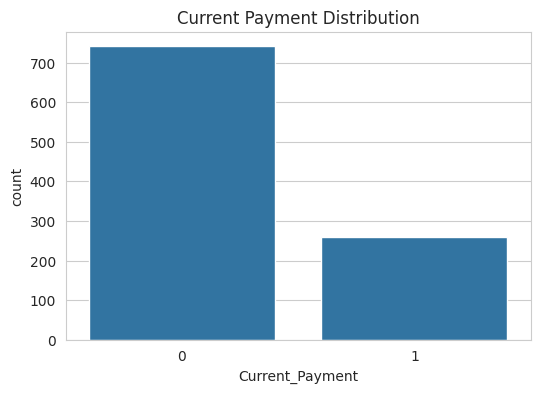

In [6]:
print("\nCurrent Payment Value Counts:")
print(df["Current_Payment"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Current_Payment", data=df)
plt.title("Current Payment Distribution")
plt.show()

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("\nTop Missing Values:")
if len(missing) > 0:
    print(missing.sort_values(ascending=False).head(20))
else:
    print("No missing values found.")



Top Missing Values:
Deceased1_DateOfDeath          1000
Deceased1_PlaceOfDeath         1000
Judgements1_PersonName         1000
Judgements1_Plaintiff          1000
Judgements1_Attorneys          1000
Address1_ComplexNumber          717
Employer2_EmployerTelephone     496
Employer1_EmployerTelephone     480
Person1_MarriageDate            479
CellNumber1_TelNumber           428
HomeNumber1_TelNumber           416
CellNumber3_Score               414
WorkNumber1_TelNumber           413
WorkNumber3_LatestDate          413
HomeNumber3_Score               412
CellNumber1_LatestDate          412
HomeNumber1_Score               411
HomeNumber2_TelType             406
WorkNumber3_Score               403
HomeNumber3_LatestDate          403
dtype: int64


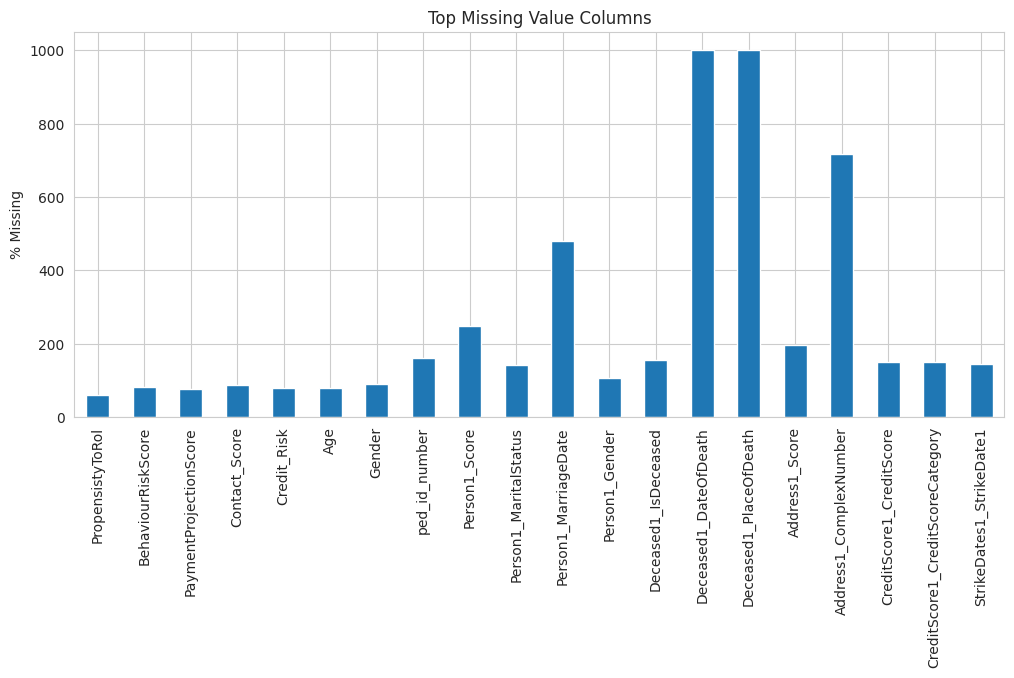

In [8]:
missing.head(20).plot(
    y="Missing_%",
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Missing Value Columns")
plt.ylabel("% Missing")
plt.show()

In [9]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing.sort_values(
    'Missing_Percentage',
    ascending=False
)

print(missing.head(30))

                             Missing_Count  Missing_Percentage
Deceased1_PlaceOfDeath                1000               100.0
Deceased1_DateOfDeath                 1000               100.0
Judgements1_PersonName                1000               100.0
Judgements1_Plaintiff                 1000               100.0
Judgements1_Attorneys                 1000               100.0
Address1_ComplexNumber                 717                71.7
Employer2_EmployerTelephone            496                49.6
Employer1_EmployerTelephone            480                48.0
Person1_MarriageDate                   479                47.9
CellNumber1_TelNumber                  428                42.8
HomeNumber1_TelNumber                  416                41.6
CellNumber3_Score                      414                41.4
WorkNumber3_LatestDate                 413                41.3
WorkNumber1_TelNumber                  413                41.3
CellNumber1_LatestDate                 412             

In [10]:
threshold = 70

cols_to_drop = missing[
    missing["Missing_Percentage"] > threshold
].index

df = df.drop(columns=cols_to_drop)

print("Columns removed:", len(cols_to_drop))

Columns removed: 6


In [11]:
leakage_cols = [
    "Current_Payment_Amount",
    "Current_Cure"
]

df = df.drop(
    columns=leakage_cols,
    errors="ignore"
)

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
print(df.isnull().sum())


Account_Key                         0
Billing_Num                         0
Book_key                            0
Book_Cycle                          0
Billing_Cycle                       0
                                 ... 
Employer1_EmployerTelephone       480
Employer2_OriginalEmployerName    351
Employer2_Occupation              324
Employer2_LatestDate              353
Employer2_EmployerTelephone       496
Length: 138, dtype: int64


In [14]:
if "Recency" in df.columns:

    df["Never_Paid_Flag"] = (
        df["Recency"] == 9999
    ).astype(int)

    df["Recency"] = df["Recency"].replace(
        9999,
        np.nan
    )

In [15]:
# Numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Features:")
print(numerical_features)
print(f"\nTotal Numerical Features: {len(numerical_features)}")

Numerical Features:
['Account_Key', 'Billing_Num', 'Book_key', 'Billing_Cycle', 'Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 'Instalment', 'Opening_Balance', 'Opening_Arrears', 'Opening_Total_Due', 'Opening_acc_status', 'Opening_acc_age', 'Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days', 'Due_90days', 'Due_120days', 'Due_150days', 'Due_180days', 'Due_210days', 'Current_per', 'Xdays_per', '30days_per', '60days_per', '90days_per', '120days_per', '150days_per', '180days_per', '210days_per', 'Deliquency', 'DC', 'TDtoBal', 'ARtoBal', 'Recency', 'Account_Age', 'Case_Age', 'Original_Band', 'Current_Band', 'Existing_Account', 'PropensistyToRol', 'BehaviourRiskScore', 'PaymentProjectionScore', 'Digigroup', 'Contact_Score', 'Credit_Risk', 'Missing', 'PContacts', 'PRPCs', 'PSMSs', 'PEmails', 'PLetters', 'PDOs', 'PPTPs', 'PAttempts', 'Previous_Account', 'Previous_Total_Due', 'Previous_Payment', 'Previous_Payment_Amount', 'Previous_Payment_Perc', 'Previous_Cure', 'Current_Payment', 'Age', 'Ge

Categorical Features:
['Book_Cycle', 'Person1_MaritalStatus', 'Person1_MarriageDate', 'Person1_Gender', 'Deceased1_IsDeceased', 'CreditScore1_CreditScoreCategory', 'Income1_Confidence', 'EagleEye1_HasDefault', 'EagleEye1_HasJudgment', 'EagleEye1_IsDirector', 'EagleEye1_UnderDebtReview', 'EagleEye1_OwnsProperty', 'EagleEye1_LastEmploymentUpdate', 'EagleEye1_HasPPAccounts', 'EagleEye1_HasPPAdverse', 'CellNumber1_TelType', 'CellNumber1_LatestDate', 'CellNumber2_TelType', 'CellNumber2_LatestDate', 'CellNumber3_TelType', 'CellNumber3_LatestDate', 'WorkNumber1_TelType', 'WorkNumber1_LatestDate', 'WorkNumber2_TelType', 'WorkNumber2_LatestDate', 'WorkNumber3_TelType', 'WorkNumber3_LatestDate', 'HomeNumber1_TelType', 'HomeNumber1_LatestDate', 'HomeNumber2_TelType', 'HomeNumber2_LatestDate', 'HomeNumber3_TelType', 'HomeNumber3_LatestDate', 'Employer1_OriginalEmployerName', 'Employer1_Occupation', 'Employer1_LatestDate', 'Employer2_OriginalEmployerName', 'Employer2_Occupation', 'Employer2_LatestD

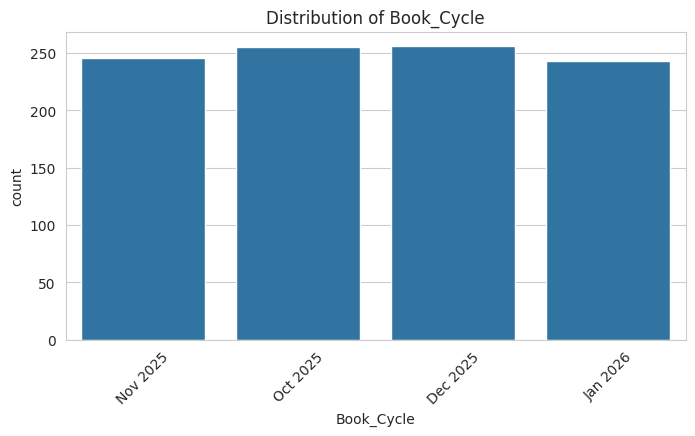

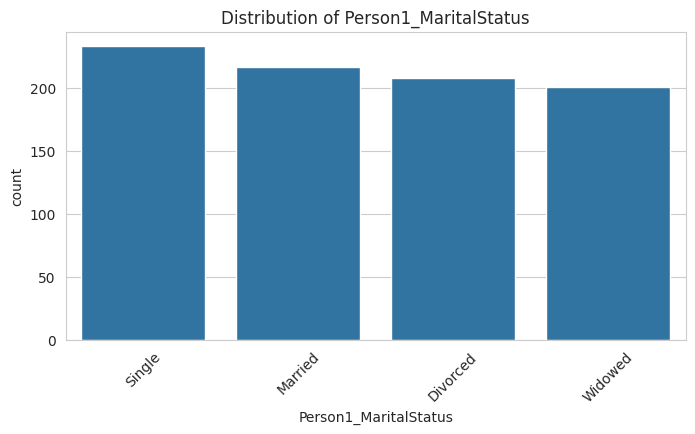

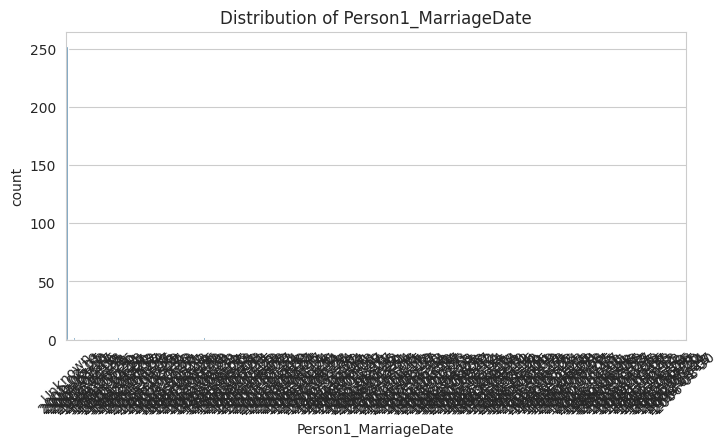

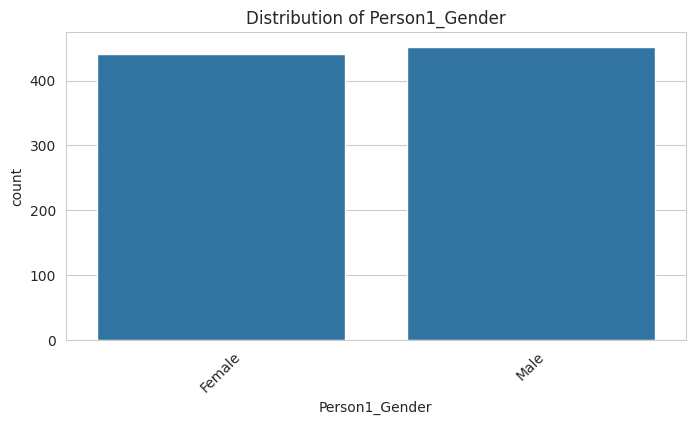

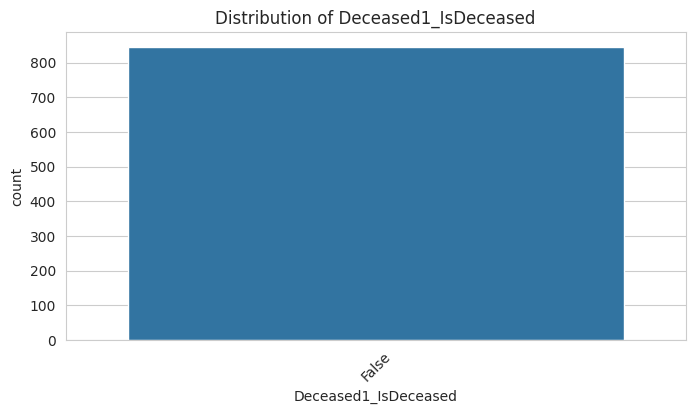

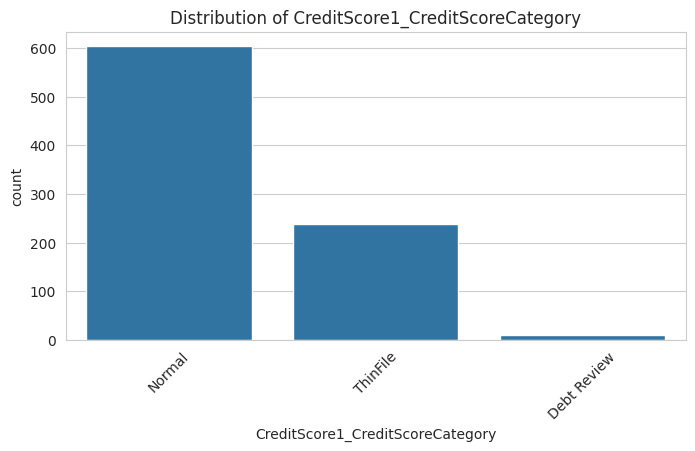

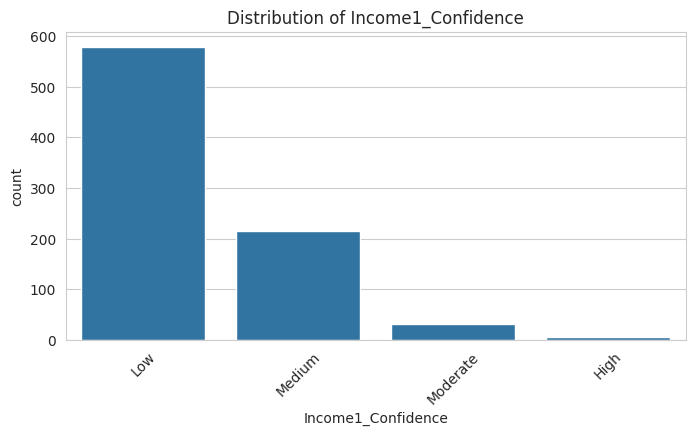

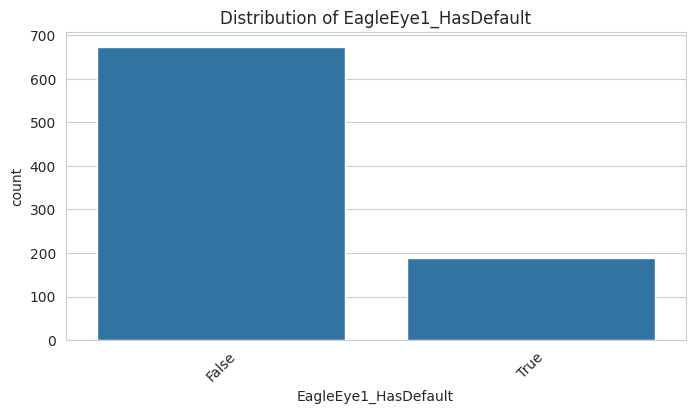

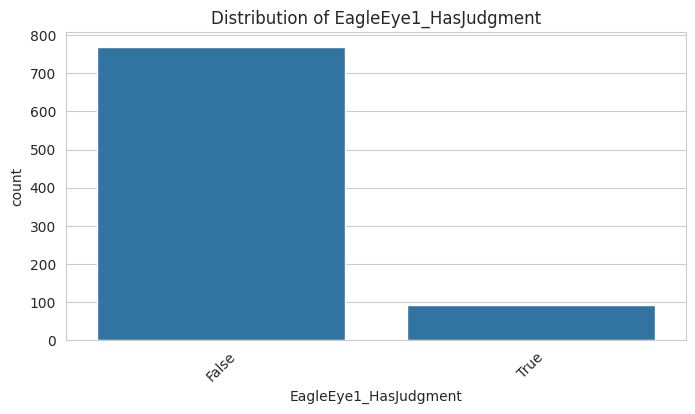

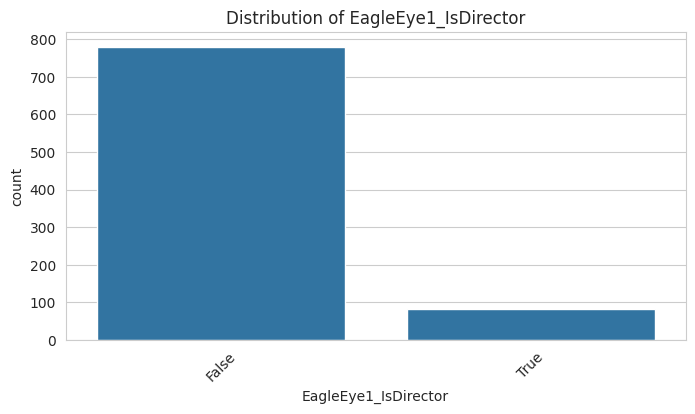

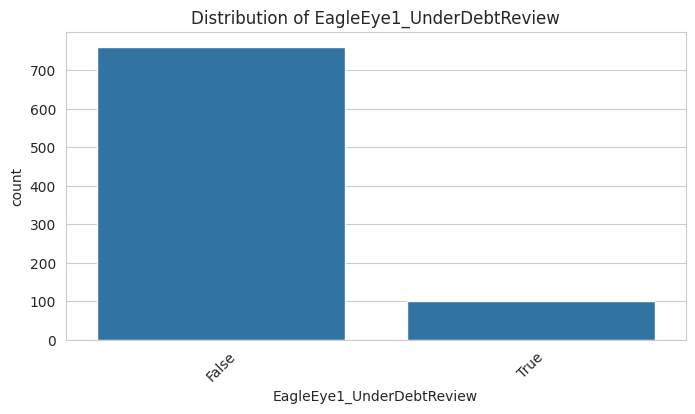

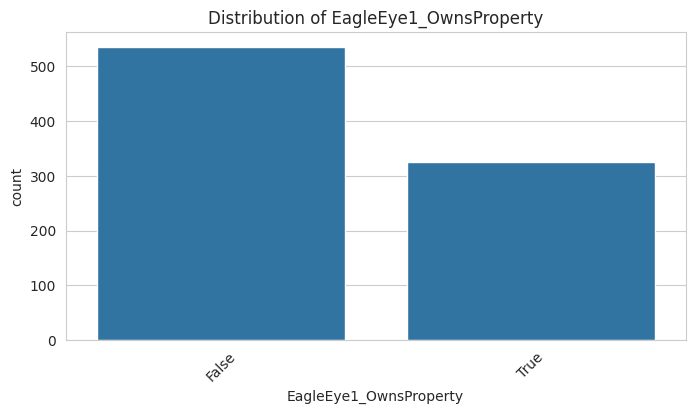

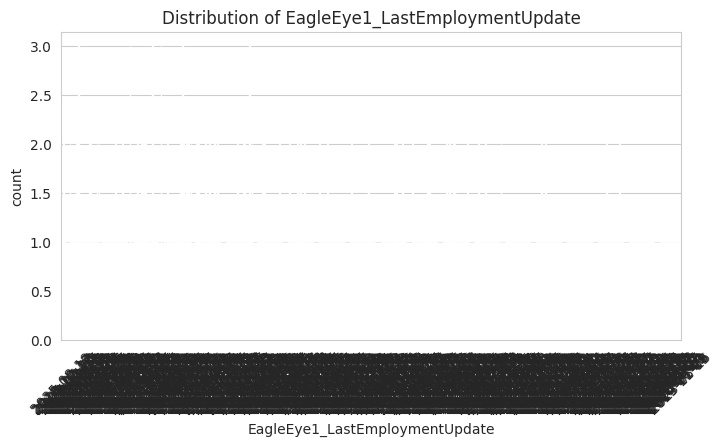

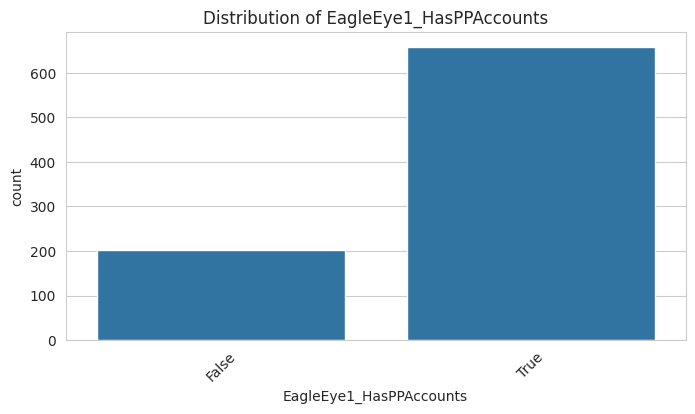

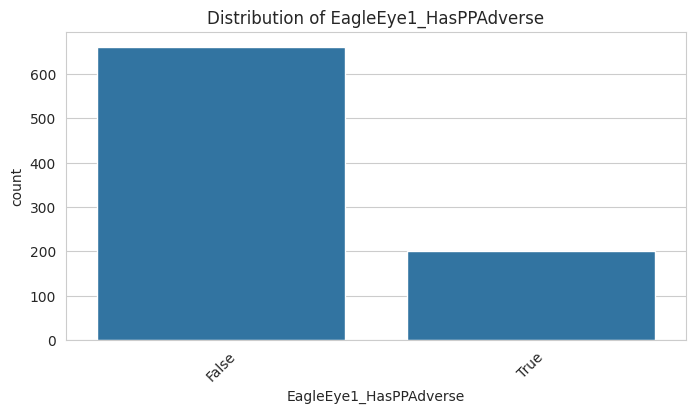

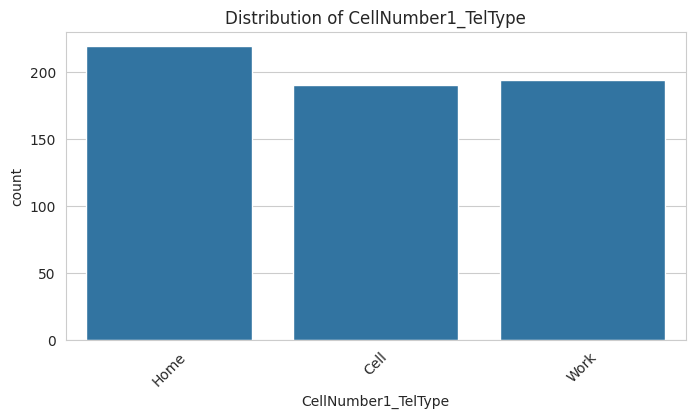

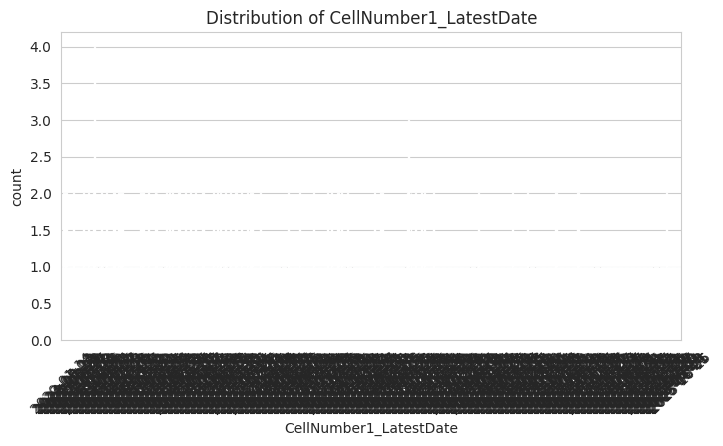

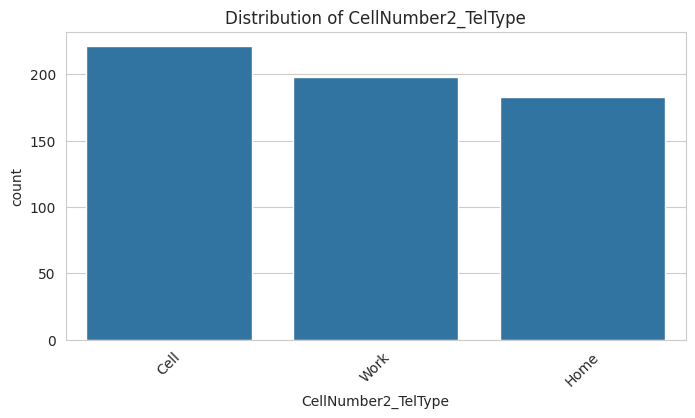

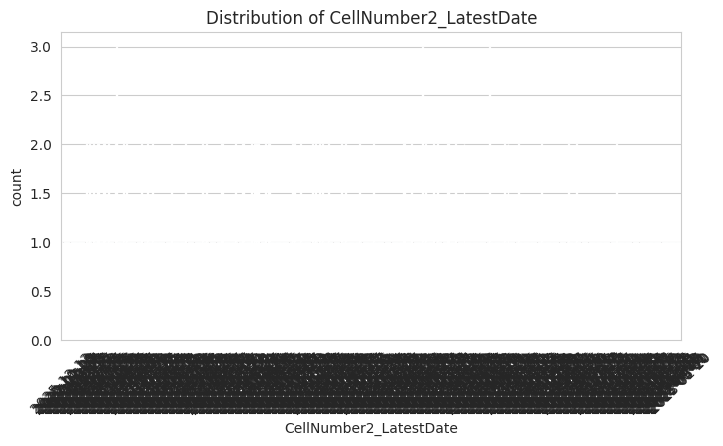

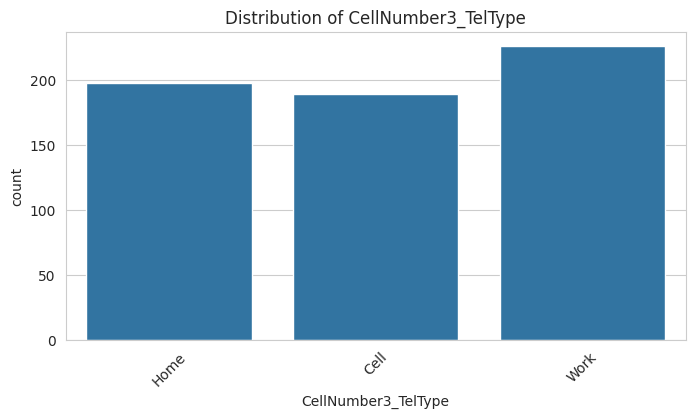

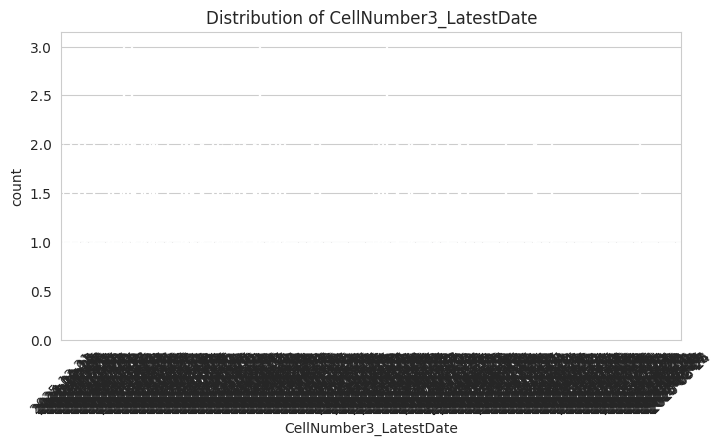

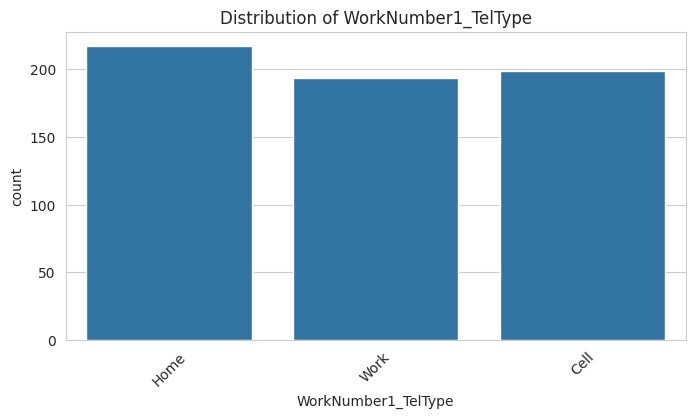

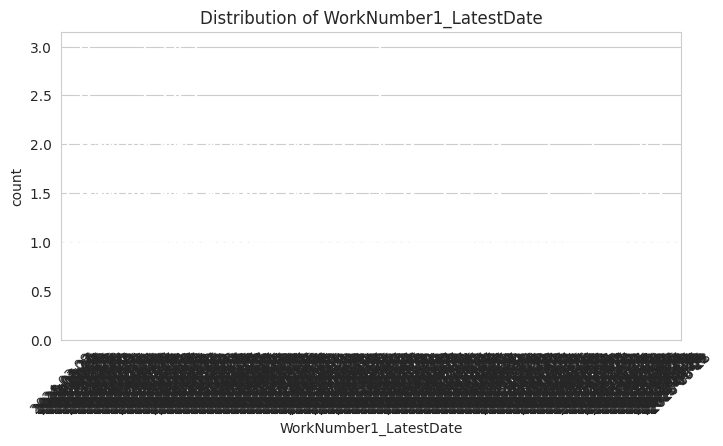

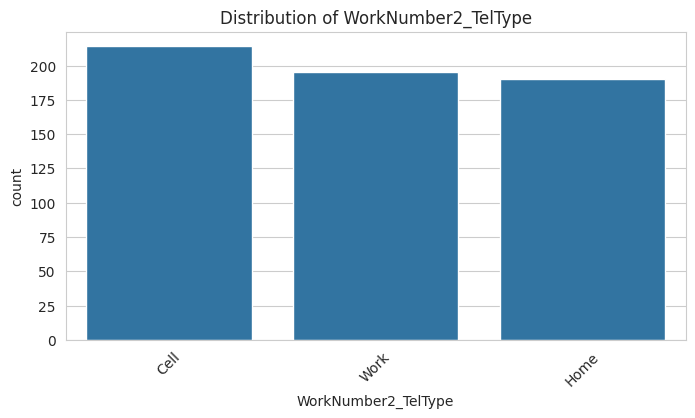

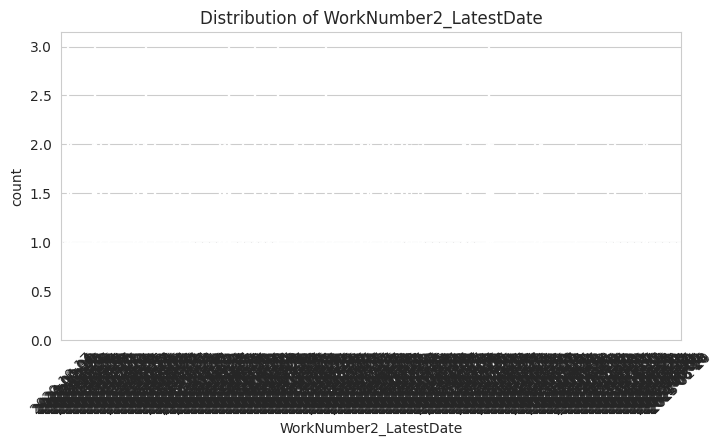

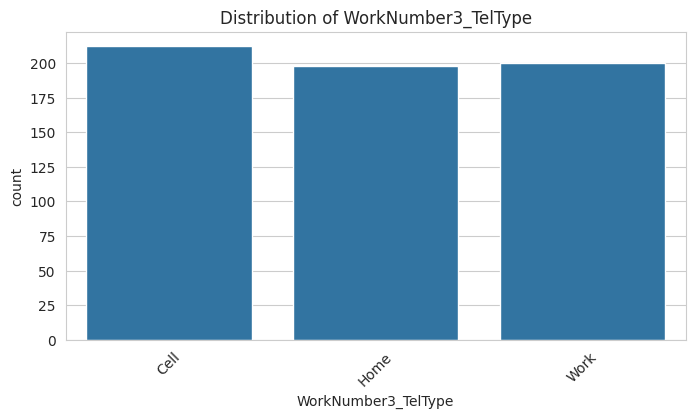

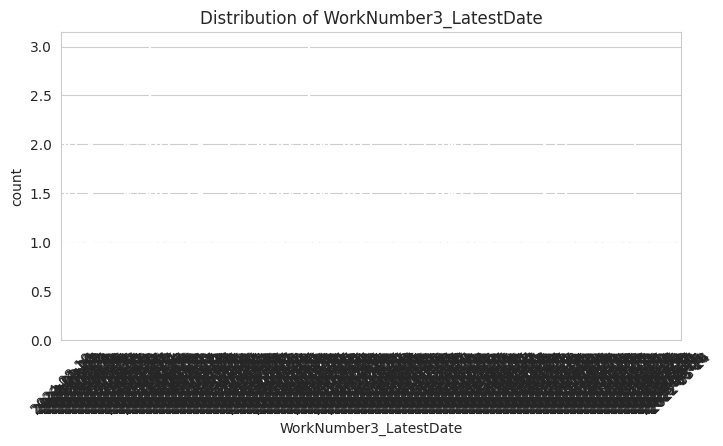

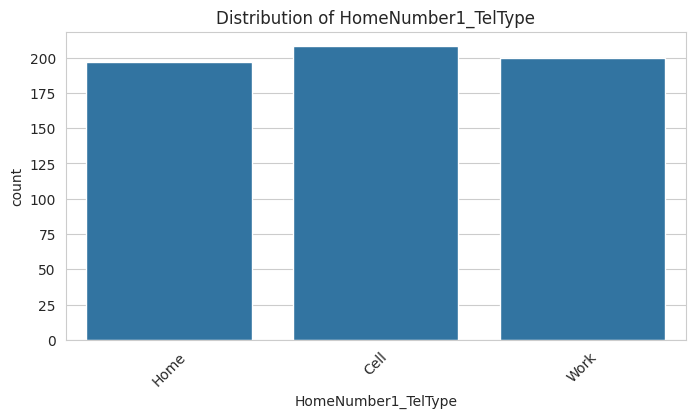

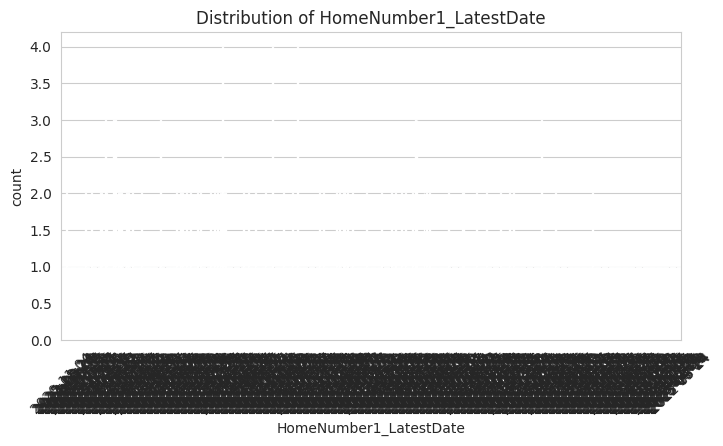

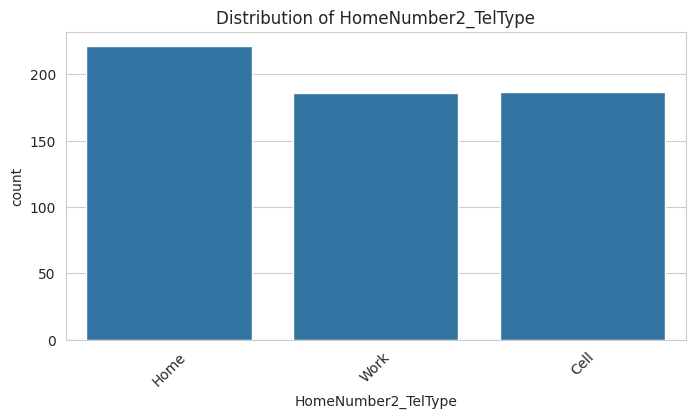

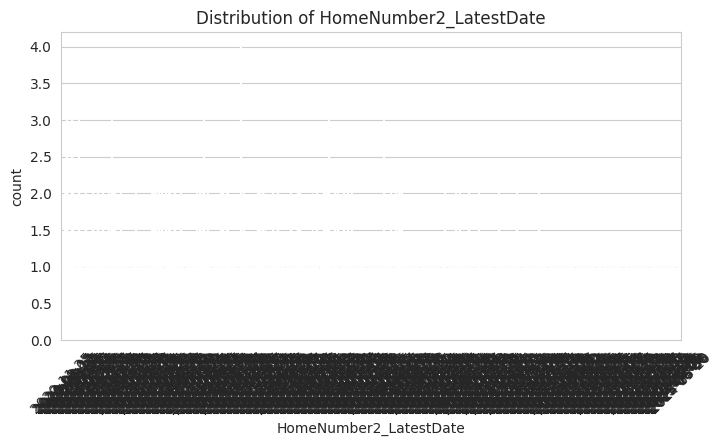

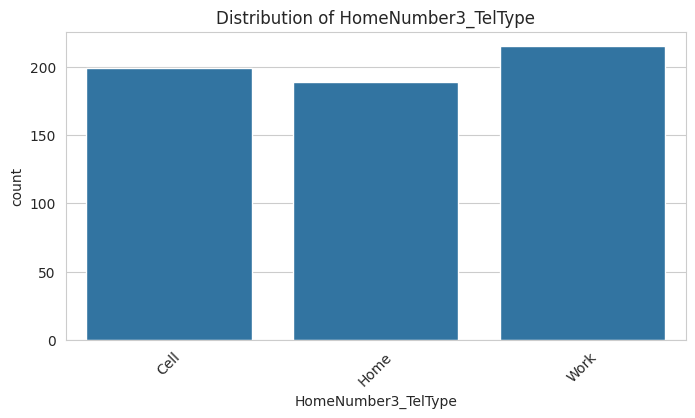

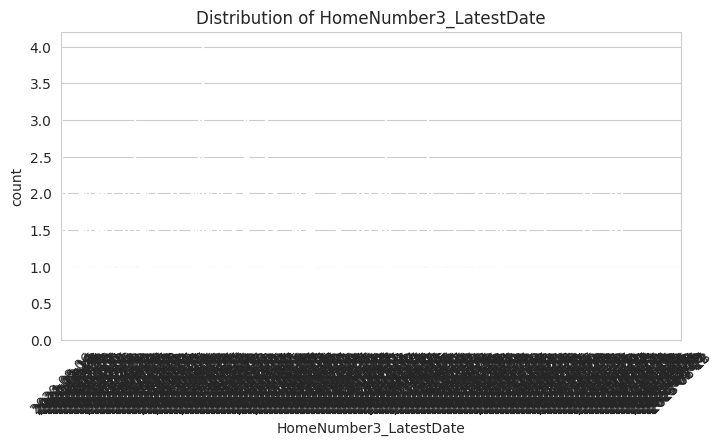

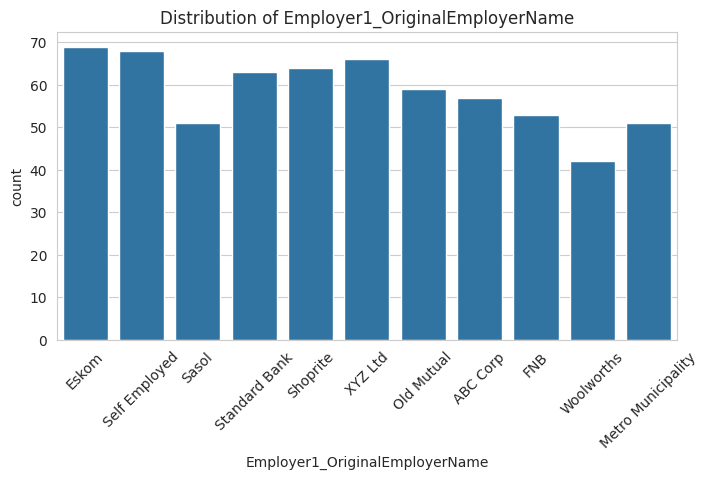

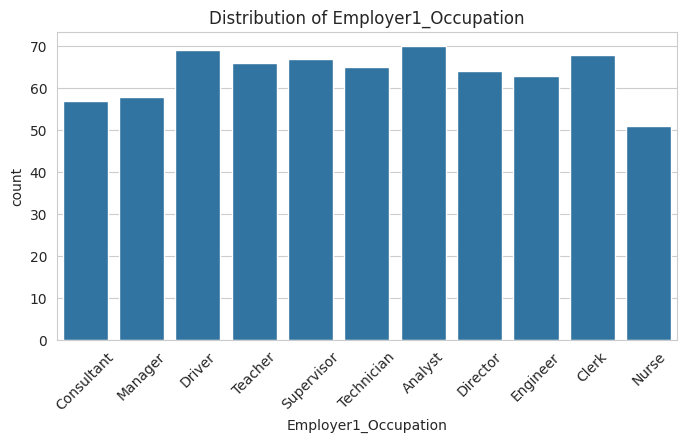

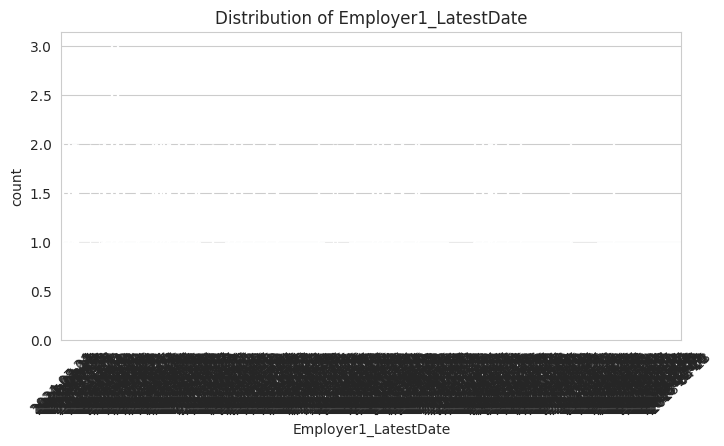

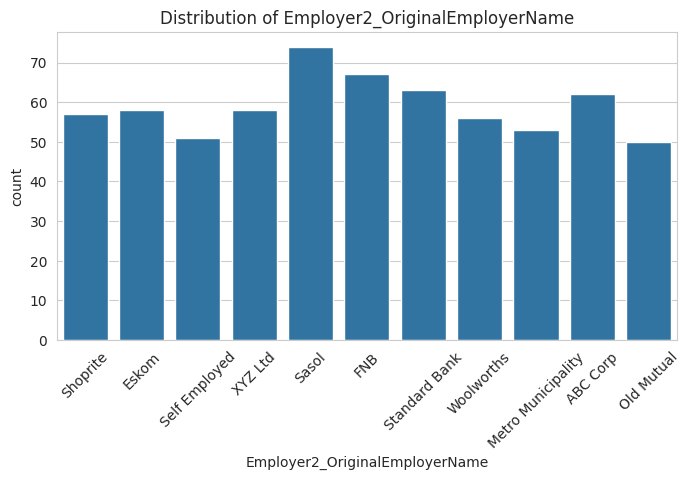

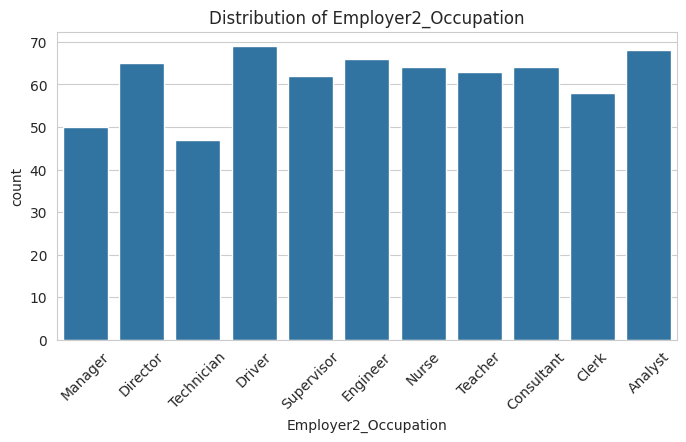

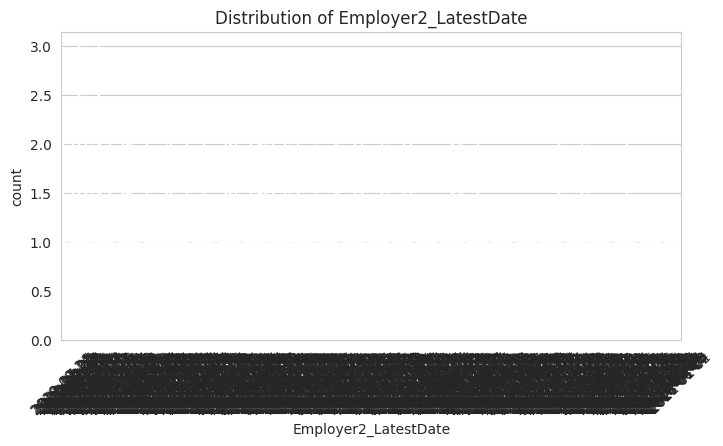

In [16]:
# Categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical Features:")
print(categorical_features)
print(f"\nTotal Categorical Features: {len(categorical_features)}")
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
# Boolean columns
categorical_features = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(categorical_features)

['Book_Cycle', 'Person1_MaritalStatus', 'Person1_MarriageDate', 'Person1_Gender', 'Deceased1_IsDeceased', 'CreditScore1_CreditScoreCategory', 'Income1_Confidence', 'EagleEye1_HasDefault', 'EagleEye1_HasJudgment', 'EagleEye1_IsDirector', 'EagleEye1_UnderDebtReview', 'EagleEye1_OwnsProperty', 'EagleEye1_LastEmploymentUpdate', 'EagleEye1_HasPPAccounts', 'EagleEye1_HasPPAdverse', 'CellNumber1_TelType', 'CellNumber1_LatestDate', 'CellNumber2_TelType', 'CellNumber2_LatestDate', 'CellNumber3_TelType', 'CellNumber3_LatestDate', 'WorkNumber1_TelType', 'WorkNumber1_LatestDate', 'WorkNumber2_TelType', 'WorkNumber2_LatestDate', 'WorkNumber3_TelType', 'WorkNumber3_LatestDate', 'HomeNumber1_TelType', 'HomeNumber1_LatestDate', 'HomeNumber2_TelType', 'HomeNumber2_LatestDate', 'HomeNumber3_TelType', 'HomeNumber3_LatestDate', 'Employer1_OriginalEmployerName', 'Employer1_Occupation', 'Employer1_LatestDate', 'Employer2_OriginalEmployerName', 'Employer2_Occupation', 'Employer2_LatestDate']


Target Variable: Current_Payment

Target Distribution:
Current_Payment
0    741
1    259
Name: count, dtype: int64

Target Percentage Distribution:
Current_Payment
0    74.1
1    25.9
Name: proportion, dtype: float64


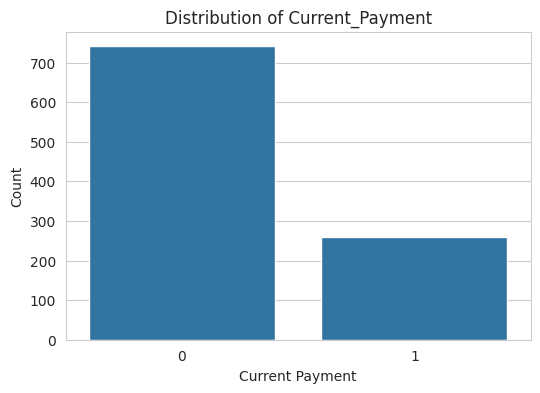

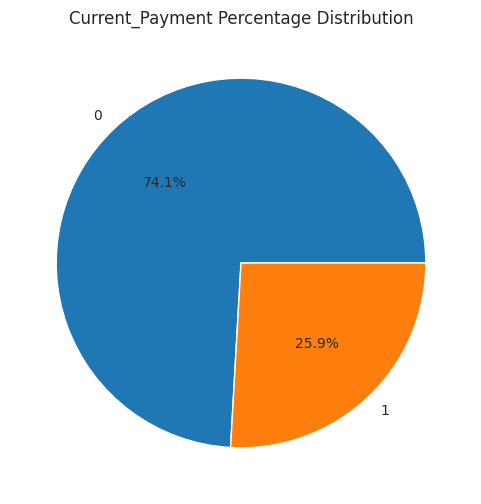

In [18]:
print("Target Variable: Current_Payment")

# Distribution
target_counts = df["Current_Payment"].value_counts()
print("\nTarget Distribution:")
print(target_counts)

# Percentage Distribution
target_percent = round(
    df["Current_Payment"].value_counts(normalize=True) * 100,
    2
)

print("\nTarget Percentage Distribution:")
print(target_percent)

# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x="Current_Payment", data=df)
plt.title("Distribution of Current_Payment")
plt.xlabel("Current Payment")
plt.ylabel("Count")
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
df["Current_Payment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Current_Payment Percentage Distribution")
plt.ylabel("")
plt.show()


Age Statistics:
count    921.000000
mean      46.550489
std       16.841005
min       18.000000
25%       32.000000
50%       47.000000
75%       61.000000
max       75.000000
Name: Age, dtype: float64


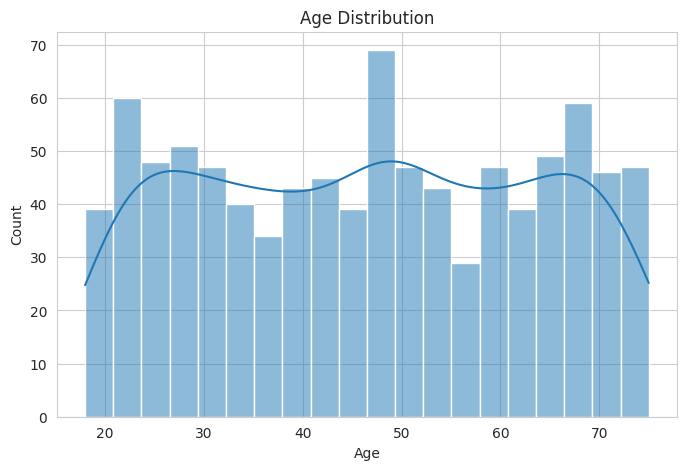

In [19]:
print("\nAge Statistics:")
print(df["Age"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()



Balance Statistics:
count     1000.000000
mean     40603.320140
std      22716.502572
min        539.050000
25%      20601.160000
50%      41429.610000
75%      59682.642500
max      79953.220000
Name: Balance, dtype: float64


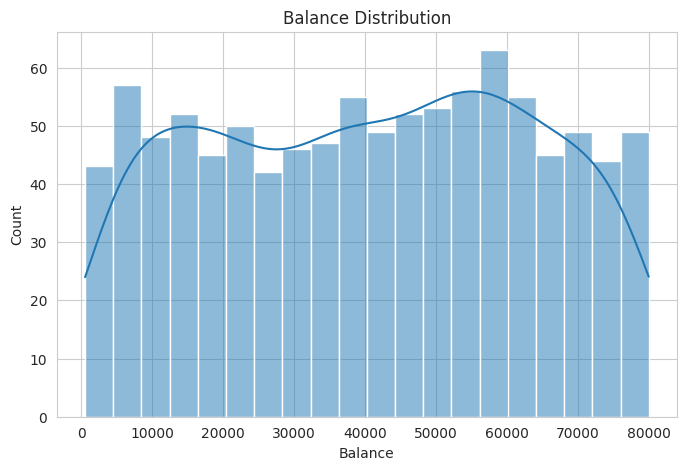

In [20]:
print("\nBalance Statistics:")
print(df["Balance"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["Balance"], bins=20, kde=True)
plt.title("Balance Distribution")
plt.show()


Delinquency Counts:
Deliquency
1    410
3    117
2     99
4     90
5     82
6     73
8     55
7     45
9     29
Name: count, dtype: int64


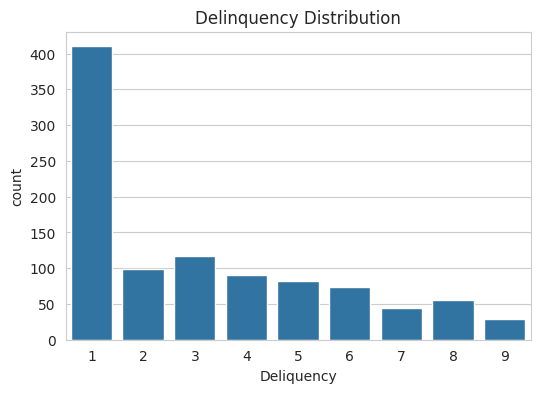

In [21]:
print("\nDelinquency Counts:")
print(df["Deliquency"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Deliquency", data=df)
plt.title("Delinquency Distribution")
plt.show()


In [22]:
print("\nPrevious Payment Counts:")
print(df["Previous_Payment"].value_counts())



Previous Payment Counts:
Previous_Payment
0    742
1    258
Name: count, dtype: int64


In [23]:
print("\nAverage Balance by Current Payment:")
print(df.groupby("Current_Payment")["Balance"].mean())

print("\nAverage Delinquency by Current Payment:")
print(df.groupby("Current_Payment")["Deliquency"].mean())

print("\nAverage Age by Current Payment:")
print(df.groupby("Current_Payment")["Age"].mean())



Average Balance by Current Payment:
Current_Payment
0    40587.155169
1    40649.568185
Name: Balance, dtype: float64

Average Delinquency by Current Payment:
Current_Payment
0    2.931174
1    3.903475
Name: Deliquency, dtype: float64

Average Age by Current Payment:
Current_Payment
0    46.459302
1    46.819742
Name: Age, dtype: float64



Recency Statistics:
count    753.000000
mean      23.088977
std       16.184485
min        0.000000
25%       10.000000
50%       20.000000
75%       32.000000
max       80.000000
Name: Recency, dtype: float64


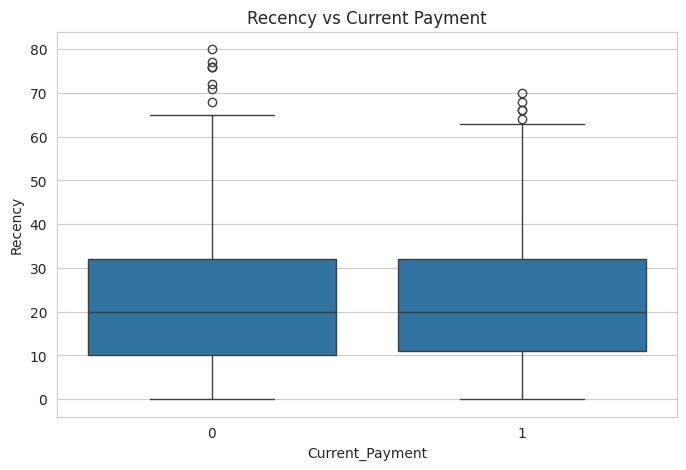

In [24]:
print("\nRecency Statistics:")
print(df["Recency"].describe())

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Current_Payment",
    y="Recency",
    data=df
)
plt.title("Recency vs Current Payment")
plt.show()

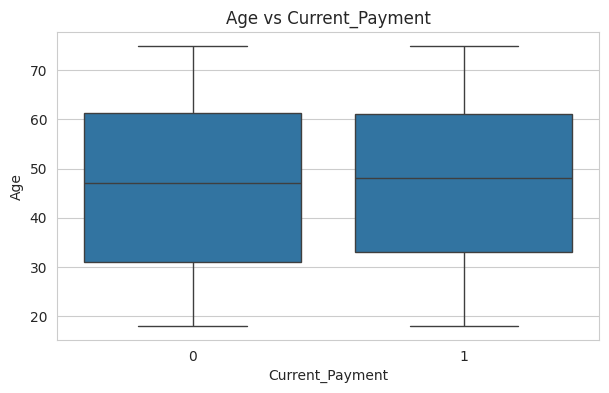

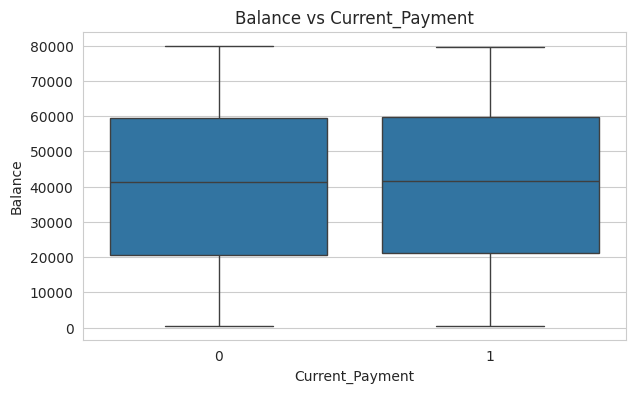

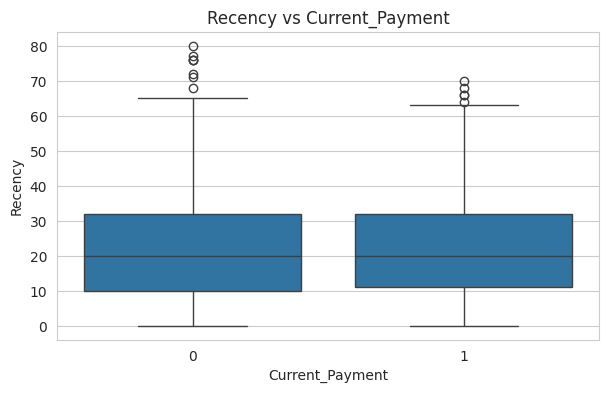

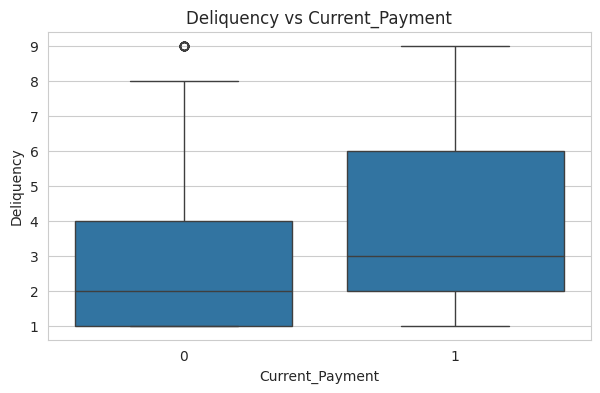

In [25]:
numerical_cols = ["Age", "Balance", "Recency", "Deliquency"]

for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(
        x="Current_Payment",
        y=col,
        data=df
    )
    plt.title(f"{col} vs Current_Payment")
    plt.show()

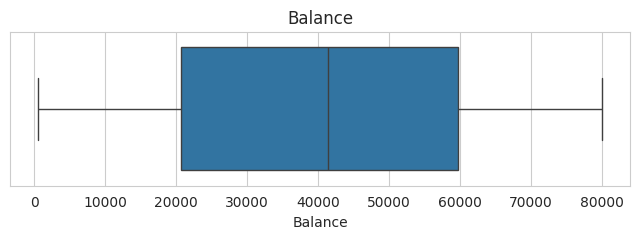

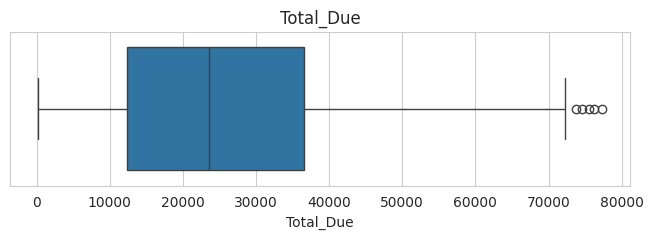

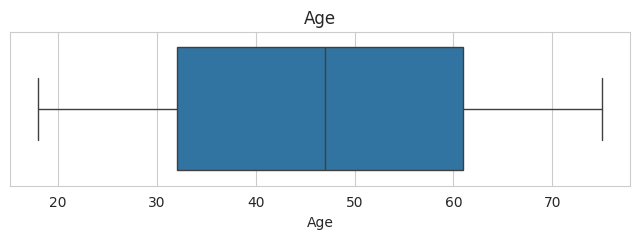

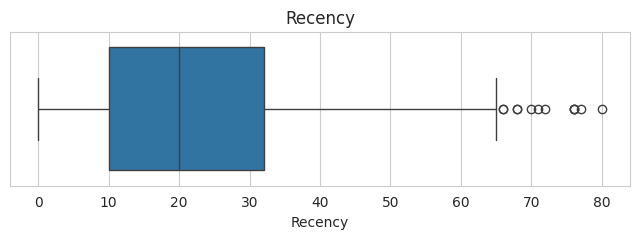

In [26]:
important_features = [
    "Balance",
    "Total_Due",
    "Age",
    "Recency"
]
for col in important_features:

    if col in df.columns:

        plt.figure(figsize=(8,2))

        sns.boxplot(
            x=df[col]
        )

        plt.title(col)

        plt.show()


Correlation Matrix:


,Balance,Deliquency,Recency,Age,Current_Payment
Balance,1.000000,-0.040158,-0.056172,0.021477,0.001204
Deliquency,-0.040158,1.000000,-0.063777,-0.023115,0.175072
Recency,-0.056172,-0.063777,1.000000,-0.021168,-0.012626
Age,0.021477,-0.023115,-0.021168,1.000000,0.009309
Current_Payment,0.001204,0.175072,-0.012626,0.009309,1.000000


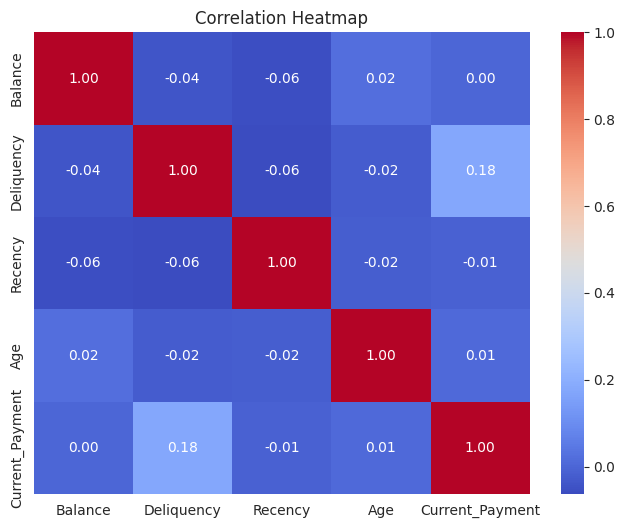

In [27]:
corr_cols = [
    "Balance",
    "Deliquency",
    "Recency",
    "Age",
    "Current_Payment"
]

corr = df[corr_cols].corr()

print("\nCorrelation Matrix:")
display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

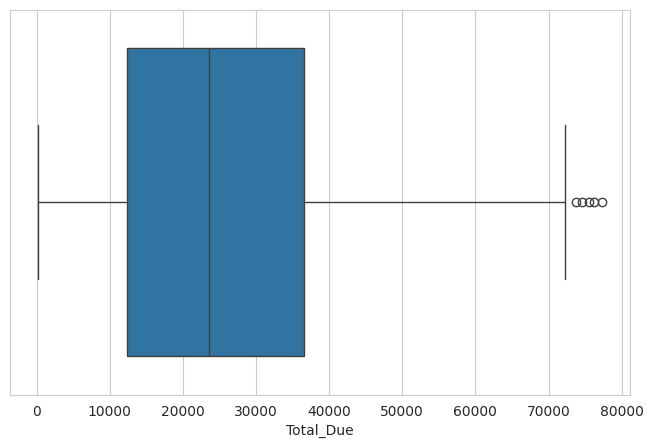

In [28]:
sns.boxplot(x=df["Total_Due"])
plt.show()

In [29]:
pd.crosstab(
    df["Gender"],
    df["Current_Payment"],
    normalize="index"
)

Current_Payment,0,1
Gender,,
1.0,0.730159,0.269841
2.0,0.759574,0.240426


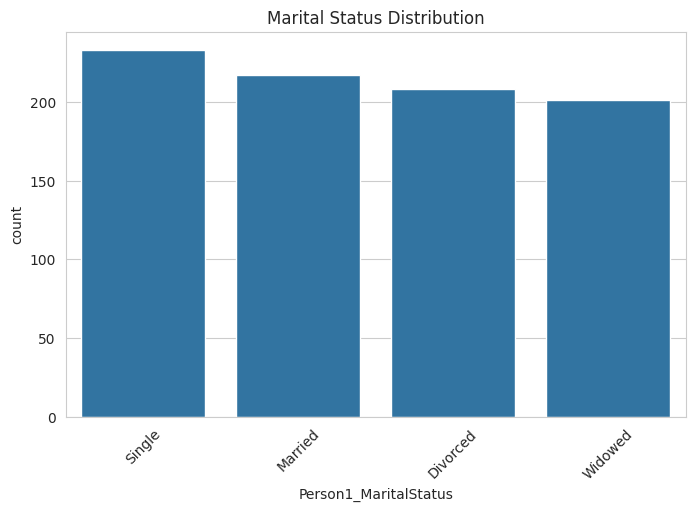

In [30]:
df["Person1_MaritalStatus"].value_counts(dropna=False)
plt.figure(figsize=(8,5))

sns.countplot(
    x="Person1_MaritalStatus",
    data=df
)

plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()

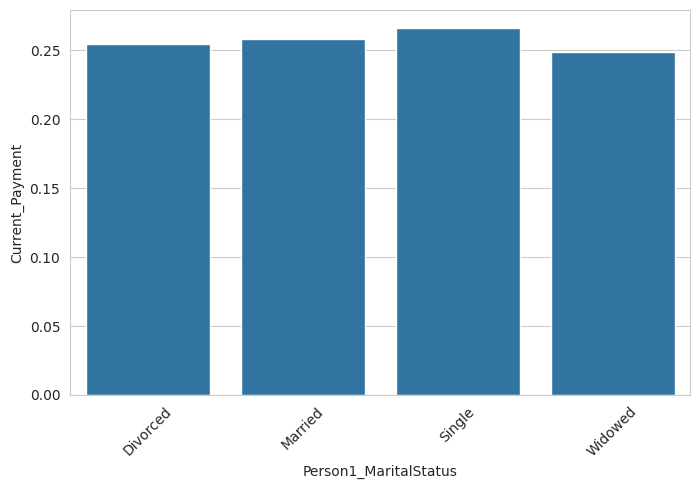

In [31]:
if "Person1_MaritalStatus" in df.columns:

    marital_payment = (
        df.groupby(
            "Person1_MaritalStatus"
        )["Current_Payment"]
        .mean()
        .reset_index()
    )

    sns.barplot(
        x="Person1_MaritalStatus",
        y="Current_Payment",
        data=marital_payment
    )

    plt.xticks(rotation=45)

    plt.show()

In [32]:
from scipy.stats import pointbiserialr

target = 'Current_Payment'

numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    if col != target:
        corr, p = pointbiserialr(df[target], df[col])
        print(f"{col}: Correlation={corr:.4f}, P-value={p:.4f}")

Account_Key: Correlation=0.0311, P-value=0.3261
Billing_Num: Correlation=-0.0106, P-value=0.7370
Book_key: Correlation=-0.0205, P-value=0.5166
Billing_Cycle: Correlation=-0.0347, P-value=0.2725
Balance: Correlation=0.0012, P-value=0.9697
BAR: Correlation=-0.0158, P-value=0.6172
Total_Due: Correlation=-0.0068, P-value=0.8311
TDtoBRatio: Correlation=-0.0158, P-value=0.6172
Instalment: Correlation=0.0076, P-value=0.8107
Opening_Balance: Correlation=0.0028, P-value=0.9296
Opening_Arrears: Correlation=-0.0071, P-value=0.8231
Opening_Total_Due: Correlation=-0.0080, P-value=0.7997
Opening_acc_status: Correlation=nan, P-value=nan
Opening_acc_age: Correlation=0.0026, P-value=0.9341
Current_Due: Correlation=-0.1718, P-value=0.0000
Xdays_Due: Correlation=0.1479, P-value=0.0000
Due_30days: Correlation=0.1100, P-value=0.0005
Due_60days: Correlation=0.0964, P-value=0.0023
Due_90days: Correlation=0.1313, P-value=0.0000
Due_120days: Correlation=0.1026, P-value=0.0012
Due_150days: Correlation=0.0495, P

/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [33]:
results = []

numeric_cols = df.select_dtypes(
    include=["int64","float64"]
).columns

numeric_cols = [
    col
    for col in numeric_cols
    if col != "Current_Payment"
]

for col in numeric_cols:

    temp = df[
        ["Current_Payment", col]
    ].dropna()

    corr_pb, p_value = pointbiserialr(
        temp["Current_Payment"],
        temp[col]
    )

    results.append([
        col,
        corr_pb,
        p_value
    ])

pb_corr = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Point_Biserial_Correlation",
        "P_Value"
    ]
)

pb_corr = pb_corr.sort_values(
    "Point_Biserial_Correlation",
    ascending=False
)

pb_corr.head(20)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,Feature,Point_Biserial_Correlation,P_Value
58,Previous_Total_Due,0.211375,1.454771e-11
56,PAttempts,0.199668,1.885043e-10
51,PSMSs,0.193184,7.298874e-10
24,Xdays_per,0.191450,1.040026e-09
49,PContacts,0.182108,6.626088e-09
37,Account_Age,0.175091,2.503270e-08
32,Deliquency,0.175072,2.512111e-08
33,DC,0.175072,2.512111e-08
38,Case_Age,0.174858,2.614085e-08
25,30days_per,0.167021,1.081747e-07


In [34]:
# Feature engineering

In [35]:
# Separate target
y = df['Current_Payment'].copy()
X = df.drop(columns=['Current_Payment'])

# Check class balance
print(y.value_counts())
print(y.value_counts(normalize=True))

Current_Payment
0    741
1    259
Name: count, dtype: int64
Current_Payment
0    0.741
1    0.259
Name: proportion, dtype: float64


In [36]:
null_rates = df.isnull().mean()
high_null_cols = null_rates[null_rates > 0.70].index.tolist()

print(f"Found {len(high_null_cols)} columns with >70% nulls:")
for col in high_null_cols:
    print(f"  {col}: {null_rates[col]*100:.1f}% missing")

Found 0 columns with >70% nulls:


In [37]:
free_text_and_useless = [
    'Judgements1_PersonName', 'Judgements1_Plaintiff', 'Judgements1_Attorneys',
    'Deceased1_DateOfDeath', 'Deceased1_PlaceOfDeath',
    'CellNumber1_TelNumber', 'CellNumber2_TelNumber', 'CellNumber3_TelNumber',
    'WorkNumber1_TelNumber', 'WorkNumber2_TelNumber', 'WorkNumber3_TelNumber',
    'HomeNumber1_TelNumber', 'HomeNumber2_TelNumber', 'HomeNumber3_TelNumber',
    'Employer1_OriginalEmployerName', 'Employer2_OriginalEmployerName',
    'Employer1_Occupation', 'Employer2_Occupation',
    'Employer1_EmployerTelephone', 'Employer2_EmployerTelephone',
    'Person1_MarriageDate', 'EagleEye1_LastEmploymentUpdate',
    'CellNumber1_LatestDate', 'CellNumber2_LatestDate', 'CellNumber3_LatestDate',
    'WorkNumber1_LatestDate', 'WorkNumber2_LatestDate', 'WorkNumber3_LatestDate',
    'HomeNumber1_LatestDate', 'HomeNumber2_LatestDate', 'HomeNumber3_LatestDate',
    'Employer1_LatestDate', 'Employer2_LatestDate',
    'CellNumber1_TelType', 'CellNumber2_TelType', 'CellNumber3_TelType',
    'WorkNumber1_TelType', 'WorkNumber2_TelType', 'WorkNumber3_TelType',
    'HomeNumber1_TelType', 'HomeNumber2_TelType', 'HomeNumber3_TelType',
    'CreditScore1_CreditScoreCategory',
    'Address1_ComplexNumber',
    'DebtReview1_Description',
    'Book_Cycle', 'Billing_Cycle',
]
all_cols_to_drop = list(set(high_null_cols) | set(free_text_and_useless))
df.drop(columns=all_cols_to_drop, inplace=True, errors='ignore')

In [38]:
print("Final Shape:")
print(df.shape)

df.head()

Final Shape:
(1000, 99)


,Account_Key,Billing_Num,Book_key,Balance,BAR,Total_Due,TDtoBRatio,Instalment,Opening_Balance,Opening_Arrears,...,CellNumber1_Score,CellNumber2_Score,CellNumber3_Score,WorkNumber1_Score,WorkNumber2_Score,WorkNumber3_Score,HomeNumber1_Score,HomeNumber2_Score,HomeNumber3_Score,Never_Paid_Flag
0,1104955506,2,664,54297.61,0.9245,50199.54,0.9245,1274.78,53873.66,47839.14,...,99.8,NaN,79.9,56.4,NaN,63.9,86.5,93.1,NaN,0
1,1104951152,4,6634,40717.83,0.3927,15990.69,0.3927,1382.79,38962.04,15581.78,...,70.0,NaN,96.0,95.1,98.0,73.8,97.9,95.3,66.8,0
2,1106011444,1,6637,14947.46,0.4821,7206.31,0.4821,494.67,14879.75,7089.21,...,62.0,NaN,99.0,NaN,NaN,53.0,61.6,NaN,94.5,0
3,1106019167,4,6647,44162.96,0.9494,41927.03,0.9494,1657.20,45038.49,40339.78,...,NaN,70.6,NaN,NaN,95.1,72.0,97.2,NaN,NaN,0
4,1106014362,1,664,26620.48,0.4033,10735.72,0.4033,1491.31,25297.00,11120.49,...,NaN,98.7,78.3,57.8,NaN,61.5,70.3,61.1,80.1,0


In [39]:
print("Previous_Account value counts:")
print(df['Previous_Account'].value_counts())

df['prev_account_new'] = (df['Previous_Account'] == -1).astype(int)
df['prev_account_existing'] = (df['Previous_Account'] == 1).astype(int)
df.drop(columns=['Previous_Account'], inplace=True)
print("\n  Created binary flags: prev_account_new, prev_account_existing")

# PAttempts and PRPCs: -1 means no prior contact history (new account)
# Replace with 0 since no contact attempts = 0 is logically equivalent
df['PAttempts'] = df['PAttempts'].replace(-1, 0)
df['PRPCs'] = df['PRPCs'].replace(-1, 0)
print("  PAttempts and PRPCs: replaced -1 with 0")

Previous_Account value counts:
Previous_Account
 1    498
-1    255
 0    247
Name: count, dtype: int64

  Created binary flags: prev_account_new, prev_account_existing
  PAttempts and PRPCs: replaced -1 with 0


In [40]:
# Encoding categorical variables

In [41]:
df['PAttempts'] = df['PAttempts'].replace(-1, 0)
df['PRPCs'] = df['PRPCs'].replace(-1, 0)
status_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
book_dummies = pd.get_dummies(
    df['Book_key'],
    prefix='book',
    drop_first=True
)
income_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

In [42]:
if 'Gender' in df.columns:

    df['Gender'] = df['Gender'].fillna('Unknown')

    gender_dummies = pd.get_dummies(
        df['Gender'],
        prefix='Gender',
        drop_first=True
    )

    df = pd.concat(
        [df, gender_dummies],
        axis=1
    )

    df.drop(
        columns=['Gender'],
        inplace=True
    )

    print("Gender encoded successfully")

Gender encoded successfully


In [43]:
if 'Person1_MaritalStatus' in df.columns:

    df['Person1_MaritalStatus'] = (
        df['Person1_MaritalStatus']
        .fillna('Unknown')
    )

    marital_dummies = pd.get_dummies(
        df['Person1_MaritalStatus'],
        prefix='Marital',
        drop_first=True
    )

    df = pd.concat(
        [df, marital_dummies],
        axis=1
    )

    df.drop(
        columns=['Person1_MaritalStatus'],
        inplace=True
    )

    print("Marital Status encoded successfully")

Marital Status encoded successfully


In [44]:
df['Person1_Gender'] = df['Person1_Gender'].fillna('Unknown')

gender_dummies = pd.get_dummies(
    df['Person1_Gender'],
    prefix='Person1_Gender',
    drop_first=True
)

df = pd.concat(
    [df, gender_dummies],
    axis=1
)

df.drop(
    columns=['Person1_Gender'],
    inplace=True
)

In [45]:
confidence_map = {
    'Low': 1,
    'Medium': 2,
    'Moderate': 3,
    'High': 4
}

df['Income1_Confidence'] = (
    df['Income1_Confidence']
    .map(confidence_map)
)

df['Income1_Confidence'] = (
    df['Income1_Confidence']
    .fillna(
        df['Income1_Confidence'].median()
    )
)

In [46]:
eagle_cols = [
    'EagleEye1_HasDefault',
    'EagleEye1_HasJudgment',
    'EagleEye1_IsDirector',
    'EagleEye1_UnderDebtReview',
    'EagleEye1_OwnsProperty',
    'EagleEye1_HasPPAccounts',
    'EagleEye1_HasPPAdverse'
]

for col in eagle_cols:

    df[col] = (
        df[col]
        .map({
            'True':1,
            'False':0,
            True:1,
            False:0
        })
        .fillna(0)
        .astype(int)
    )

In [47]:
print(df.select_dtypes(include='object').columns.tolist())

['Deceased1_IsDeceased']


In [48]:
remaining_nulls = df.isnull().sum()
cols_with_nulls = remaining_nulls[remaining_nulls > 0].sort_values(ascending=False)
print(f"Columns still with missing values: {len(cols_with_nulls)}")
print(cols_with_nulls)

Columns still with missing values: 25
CellNumber3_Score           414
HomeNumber3_Score           412
HomeNumber1_Score           411
WorkNumber3_Score           403
WorkNumber1_Score           398
HomeNumber2_Score           397
WorkNumber2_Score           391
CellNumber2_Score           371
CellNumber1_Score           367
Recency                     247
Person1_Score               247
Address1_Score              196
Income1_Income              170
ped_id_number               162
Deceased1_IsDeceased        154
StrikeDates1_StrikeDate3    153
CreditScore1_CreditScore    150
StrikeDates1_StrikeDate1    145
StrikeDates1_StrikeDate2    129
Contact_Score                86
BehaviourRiskScore           81
Credit_Risk                  80
Age                          79
PaymentProjectionScore       75
PropensistyToRol             61
dtype: int64


In [49]:
bureau_numeric_cols = [
    'CreditScore1_CreditScore', 'Income1_Income', 'Income1_Confidence',
    'Person1_Score', 'Address1_Score',
    'CellNumber1_Score', 'CellNumber2_Score', 'CellNumber3_Score',
    'WorkNumber1_Score', 'WorkNumber2_Score', 'WorkNumber3_Score',
    'HomeNumber1_Score', 'HomeNumber2_Score', 'HomeNumber3_Score',
    'income_band_encoded', 'debt_review_status',
]

for col in bureau_numeric_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col + '_missing'] = df[col].isnull().astype(int)

print("Created missing-indicator flags for bureau columns.")

# Impute all remaining numeric columns with the median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

print(f"Imputed remaining nulls with column medians.")
print(f"Total missing values remaining (should be 0 or only all-null cols): {df.isnull().sum().sum()}")

Created missing-indicator flags for bureau columns.
Imputed remaining nulls with column medians.
Total missing values remaining (should be 0 or only all-null cols): 154


/tmp/ipykernel_1875/3387812752.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [50]:
near_constant = []
for col in df.columns:
    vc = df[col].value_counts(normalize=True)
    if len(vc) == 0:
        near_constant.append(col)
    elif vc.iloc[0] > 0.99:
        near_constant.append(col)

if near_constant:
    print(f"Dropping near-constant columns ({len(near_constant)}):")
    for col in near_constant:
        print(f"  {col}")
    df.drop(columns=near_constant, inplace=True)
else:
    print("No near-constant columns found.")

print(f"\nFinal feature set shape: {df.shape}")
print(f"Target variable shape: {y.shape}")

Dropping near-constant columns (5):
  Opening_acc_status
  Previous_Cure
  Person1_Score
  Deceased1_IsDeceased
  Judgements1_JudgmentAmount

Final feature set shape: (1000, 113)
Target variable shape: (1000,)


In [51]:
df.to_csv("processed_features.csv", index=False)
y.to_csv("processed_target.csv", index=False)

print("Saved: processed_features.csv")
print("Saved: processed_target.csv")
print("\nVerification - null check on saved features:")
check = pd.read_csv("processed_features.csv")
print(f"  Nulls in processed_features.csv: {check.isnull().sum().sum()}")
print(f"  Shape: {check.shape}")

Saved: processed_features.csv
Saved: processed_target.csv

Verification - null check on saved features:
  Nulls in processed_features.csv: 0
  Shape: (1000, 113)


In [52]:
# Train-Test Split

In [53]:
# Define features and target
X = df.drop('Current_Payment', axis=1)
y = df['Current_Payment']

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 112)
X_test: (200, 112)
y_train: (800,)
y_test: (200,)


In [54]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [55]:
# Random forest Model

In [56]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [57]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.3).astype(int)

In [58]:
y_pred_rf = (y_prob_rf >= 0.3).astype(int)

In [59]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
auc_rf = roc_auc_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"AUC-ROC:   {auc_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")

Random Forest Results
AUC-ROC:   0.6369
F1-Score:  0.4430
Precision: 0.3302
Recall:    0.6731


In [72]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Fold Scores:", cv_scores)
print("Mean AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Fold Scores: [0.6425497  0.62861242 0.61108834 0.65556901 0.69521792]
Mean AUC: 0.6466074772199082
Standard Deviation: 0.02844356097858836


In [60]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Confusion Matrix:
[[77 71]
 [17 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.52      0.64       148
           1       0.33      0.67      0.44        52

    accuracy                           0.56       200
   macro avg       0.57      0.60      0.54       200
weighted avg       0.69      0.56      0.59       200



In [61]:
# Feature Impotance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(20))

                   Feature  Importance
35             Account_Age    0.046066
55      Previous_Total_Due    0.042723
36                Case_Age    0.042219
54               PAttempts    0.033148
88         Never_Paid_Flag    0.023253
47               PContacts    0.021687
34                 Recency    0.018826
49                   PSMSs    0.016385
40        PropensistyToRol    0.016374
48                   PRPCs    0.015977
70          Income1_Income    0.015799
12             Current_Due    0.015620
44           Contact_Score    0.015539
41      BehaviourRiskScore    0.015349
64           ped_id_number    0.014888
65          Address1_Score    0.014795
81       CellNumber3_Score    0.014649
82       WorkNumber1_Score    0.014360
0              Account_Key    0.013919
42  PaymentProjectionScore    0.013679


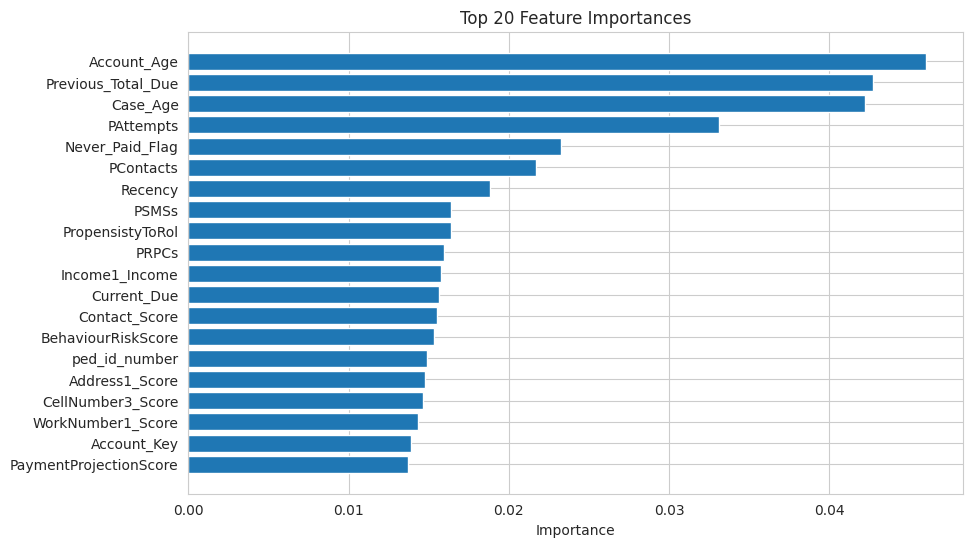

In [62]:
top20 = importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20['Feature'],
    top20['Importance']
)
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [63]:
# Hyperparamter tuning
RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, random_state=42)

In [65]:
best_rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=5,
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, random_state=42)

In [66]:
y_prob = best_rf.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.3).astype(int)

In [67]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

In [75]:
# Buisness Interpretation
"""
Customers with recent payments, lower delinquency, and higher payment projection
scores are more likely to make payments. These customers can be prioritized for
collection efforts likely to result in successful recovery.
"""

'\nCustomers with recent payments, lower delinquency, and higher payment projection\nscores are more likely to make payments. These customers can be prioritized for \ncollection efforts likely to result in successful recovery.\n'